In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [9]:
A = pd.read_csv("dataset_A_step_only.csv", parse_dates=["date"])
B = pd.read_csv("dataset_B_full_features.csv", parse_dates=["date"])

In [10]:
cat_order = ["No Watch", "Light", "Moderate", "Heavy"]
A["watch_category"] = pd.Categorical(A["watch_category"], categories=cat_order, ordered=True)
B["watch_category"] = pd.Categorical(B["watch_category"], categories=cat_order, ordered=True)
print("Data is uploaded")
print(f"Dataset A: {A.shape[0]} days ({A["date"].min().date()}) -> {A["date"].max().date()}")
print(f"Dataset B: {B.shape[0]} days ({B["date"].min().date()}) -> {B["date"].max().date()}")

Data is uploaded
Dataset A: 1573 days (2021-10-29) -> 2026-02-17
Dataset B: 1055 days (2023-03-31) -> 2026-02-17


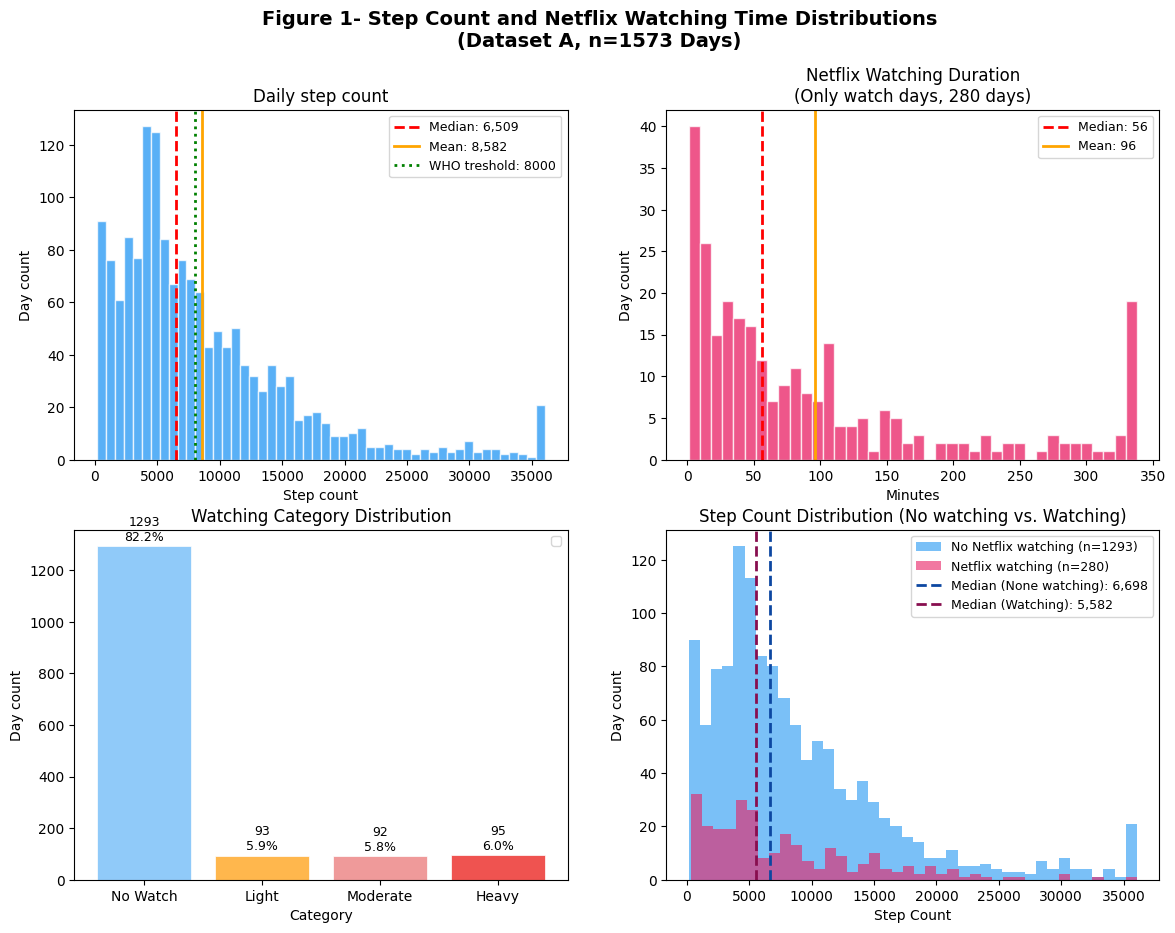

In [ ]:
#Figure 1 - Step Count and Netflix Watching Time Distributions

fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle("Figure 1- Step Count and Netflix Watching Time Distributions\n(Dataset A, n=1573 Days)", fontsize=14, fontweight="bold", y=0.98)
ax = axes[0, 0]
ax.hist(A["step_count"], bins=50, color="#2196F3", alpha=0.75, edgecolor="white")
ax.axvline(A["step_count"].median(), color="red", linewidth=2, linestyle="--", label=f"Median: {A["step_count"].median():,.0f}")
ax.axvline(A["step_count"].mean(), color="orange", linewidth=2, linestyle="-", label=f"Mean: {A["step_count"].mean():,.0f}")
ax.axvline(8000, color="green", linewidth=2, linestyle=":", label="WHO treshold: 8000")
ax.set_title("Daily step count", fontsize=12)
ax.set_xlabel("Step count")
ax.set_ylabel("Day count")
ax.legend(fontsize=9)

ax = axes[0, 1]
watch_days = A[A["watch_minutes"] > 0]["watch_minutes"]
ax.hist(watch_days, bins=40, color="#E91E63", alpha=0.75, edgecolor="white")
ax.axvline(watch_days.median(), color="red", linewidth=2, linestyle="--", label=f"Median: {watch_days.median():,.0f}")
ax.axvline(watch_days.mean(), color="orange", linewidth=2, linestyle="-", label=f"Mean: {watch_days.mean():,.0f}")
ax.set_title(f"Netflix Watching Duration\n(Only watch days, {len(watch_days)} days)", fontsize=12)
ax.set_xlabel("Minutes")
ax.set_ylabel("Day count")
ax.legend(fontsize=9)

ax = axes[1, 0]
counts = A["watch_category"].value_counts().reindex(cat_order)
colors = ["#90CAF9", "#FFB74D", "#EF9A9A", "#EF5350"]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f"{val}\n{val/len(A)*100:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_title("Watching Category Distribution", fontsize=12)
ax.set_xlabel("Category")
ax.set_ylabel("Day count")
ax.legend(fontsize=9)

ax = axes[1, 1]
no_watch_steps = A[A["watch_minutes"] == 0]["step_count"]
watch_steps = A[A["watch_minutes"] > 0]["step_count"]
ax.hist(no_watch_steps, bins=40, color="#2196F3", alpha=0.6, label=f"No Netflix watching (n={len(no_watch_steps)})")
ax.hist(watch_steps, bins=40, color="#E91E63", alpha=0.6, label=f"Netflix watching (n={len(watch_steps)})")
ax.axvline(no_watch_steps.median(), color="#0D47A1", linewidth=2, linestyle="--", label=f"Median (None watching): {no_watch_steps.median():,.0f}")
ax.axvline(watch_steps.median(), color="#880E4F", linewidth=2, linestyle="--", label=f"Median (Watching): {watch_steps.median():,.0f}")
ax.set_title(f"Step Count Distribution (No watching vs. Watching)", fontsize=12)
ax.set_xlabel("Step Count")
ax.set_ylabel("Day count")
ax.legend(fontsize=9)

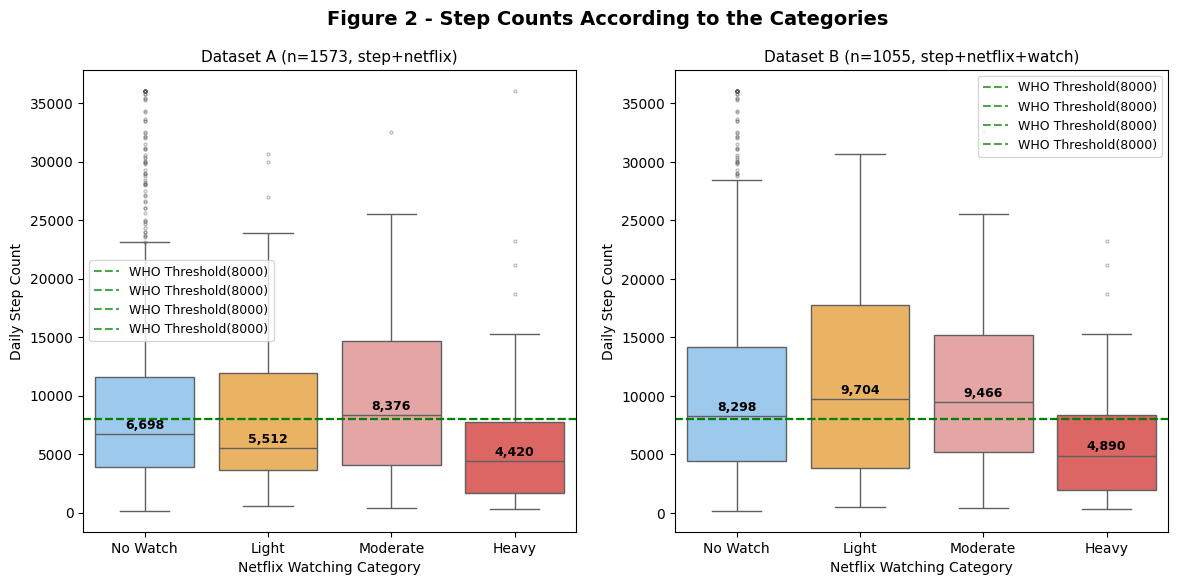

In [ ]:
#Figure 2 - Step Counts According to the Categories

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 2 - Step Counts According to the Categories", fontsize=14, fontweight="bold")
palette = {"No Watch": "#90CAF9", "Light": "#FFB74D", "Moderate": "#EF9A9A", "Heavy": "#EF5350"}

for ax, (df, title) in zip(axes, [(A, "Dataset A (n=1573, step+netflix)"), (B, "Dataset B (n=1055, step+netflix+watch)")]):
    sns.boxplot(data=df, x="watch_category", y="step_count", order=cat_order, palette=palette, ax=ax,flierprops=dict(marker="o", markersize=2, alpha=0.4))
    for i, cat in enumerate(cat_order):
        med = df[df["watch_category"] == cat]["step_count"].median()
        ax.text(i, med +200, f"{med:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold", color="black")
        ax.axhline(8000, color="green", linewidth=1.5, linestyle="--", alpha=0.7, label="WHO Threshold(8000)")
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Netflix Watching Category")
        ax.set_ylabel("Daily Step Count")
        ax.legend(fontsize=9)

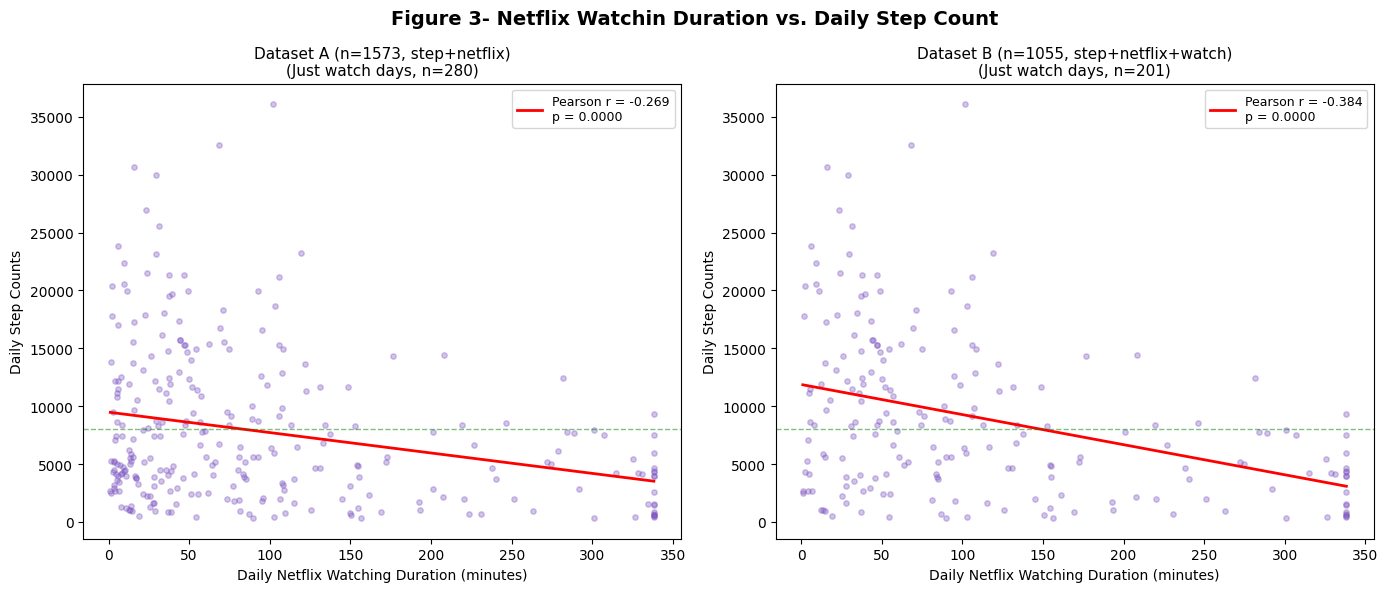

In [ ]:
#Figure 3- Netflix Watchin Duration vs. Daily Step Count

fig, axes = plt.subplots(1, 2, figsize=(14,6))
fig.suptitle("Figure 3- Netflix Watchin Duration vs. Daily Step Count", fontsize=14, fontweight="bold")

for ax, (df, title) in zip(axes, [(A, "Dataset A (n=1573, step+netflix)"), (B, "Dataset B (n=1055, step+netflix+watch)")]):
    d = df[df["watch_minutes"] > 0]
    ax.scatter(d["watch_minutes"], d["step_count"], alpha=0.35, s=15, color="#7E57C2")

    #pearson correlation and regression line
    corr, pval = stats.pearsonr(d["watch_minutes"], d["step_count"])
    m, b = np.polyfit(d["watch_minutes"], d["step_count"], 1)
    x_line = np.linspace(d["watch_minutes"].min(), d["watch_minutes"].max(), 100)
    ax.plot(x_line, m * x_line + b, color="red", linewidth=2, label=f"Pearson r = {corr:.3f}\np = {pval:.4f}")
    ax.axhline(8000, color="green", linewidth=1, linestyle="--", alpha=0.5)
    ax.set_title(f"{title}\n(Just watch days, n={len(d)})", fontsize=11)
    ax.set_xlabel("Daily Netflix Watching Duration (minutes)")
    ax.set_ylabel("Daily Step Counts")
    ax.legend(fontsize=9)

plt.tight_layout()

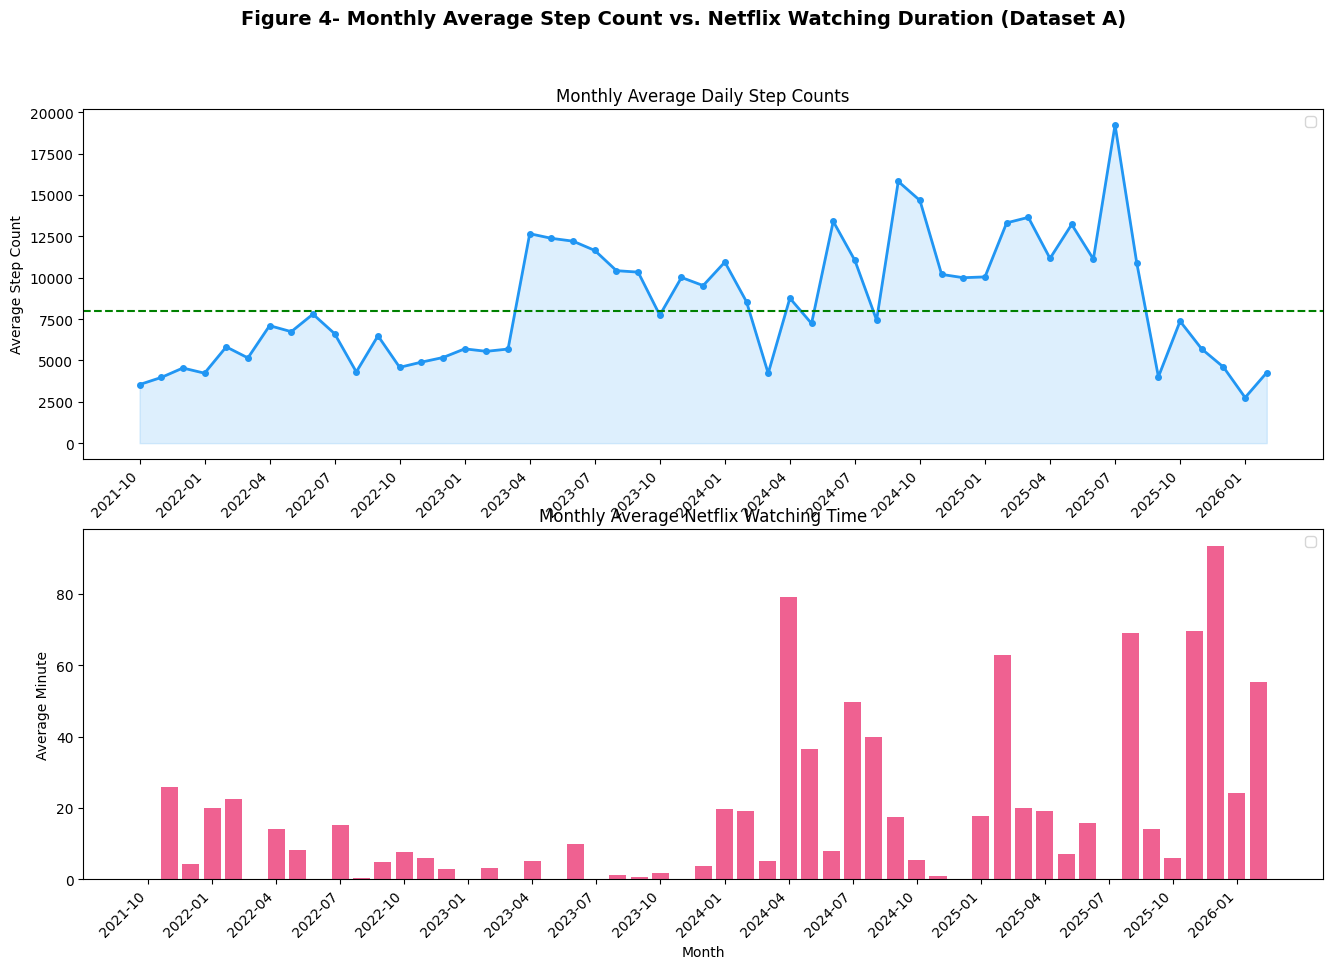

In [ ]:
#Figure 4- Monthly Average Step Count vs. Netflix Watching Duration (Dataset A)

fig, axes = plt.subplots(2, 1, figsize=(16,10))
fig.suptitle("Figure 4- Monthly Average Step Count vs. Netflix Watching Duration (Dataset A)", fontsize=14, fontweight="bold")

A_monthly = A.copy()
A_monthly["year_month"] = A_monthly["date"].dt.to_period("M")
monthly = A_monthly.groupby("year_month").agg(step_mean=("step_count", "mean"), watch_mean=("watch_minutes", "mean")).reset_index()
monthly["year_month_str"]= monthly["year_month"].astype(str)

ax = axes[0]
ax.plot(range(len(monthly)), monthly["step_mean"], color="#2196F3", linewidth=2, marker="o", markersize=4)
ax.fill_between(range(len(monthly)), monthly["step_mean"], alpha= 0.15, color="#2196F3")
ax.axhline(8000, color="green", linewidth=1.5, linestyle="--")
ax.set_title("Monthly Average Daily Step Counts")
ax.set_ylabel("Average Step Count")
ax.set_xticks(range(0, len(monthly), 3))
ax.set_xticklabels(monthly["year_month_str"][::3], rotation=45, ha="right");
ax.legend()

ax = axes[1]
ax.bar(range(len(monthly)), monthly["watch_mean"], color="#E91E63", alpha=0.7, width=0.8)
ax.set_title("Monthly Average Netflix Watching Time")
ax.set_ylabel("Average Minute")
ax.set_xlabel("Month")
ax.set_xticks(range(0, len(monthly), 3))
ax.set_xticklabels(monthly["year_month_str"][::3], rotation=45, ha="right")
ax.legend()


Text(0.5, 1.0, 'Figure 5- Corelation Heat Map (Dataset B, n=1055)')

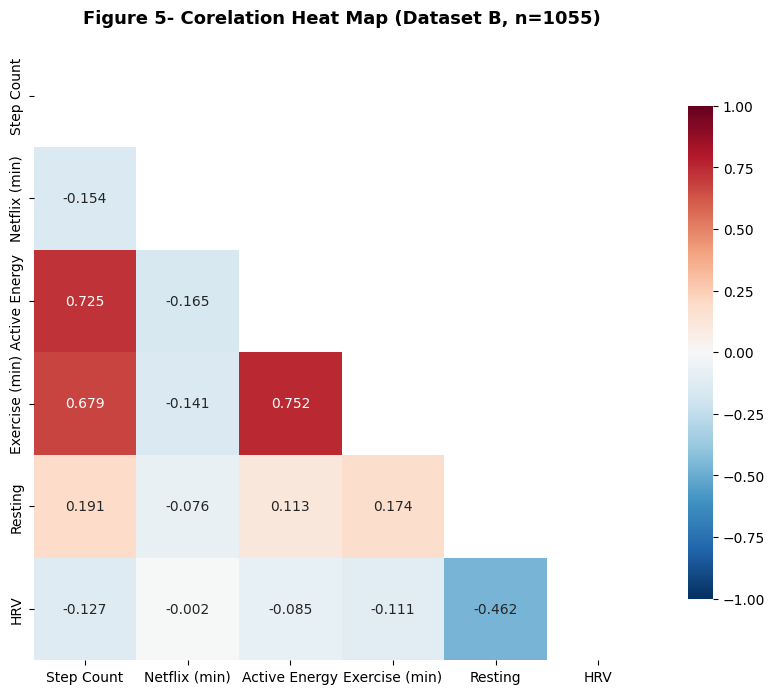

In [47]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_cols = ["step_count", "watch_minutes", "active_energy_kcal",
             "exercise_minutes", "resting_hr_bpm", "hrv_ms"]
corr_labels = ["Step Count", "Netflix (min)", "Active Energy",
               "Exercise (min)", "Resting", "HRV"]
corr_matrix = B[corr_cols].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".3f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Figure 5- Corelation Heat Map (Dataset B, n=1055)",
             fontsize=13, fontweight="bold", pad=15)


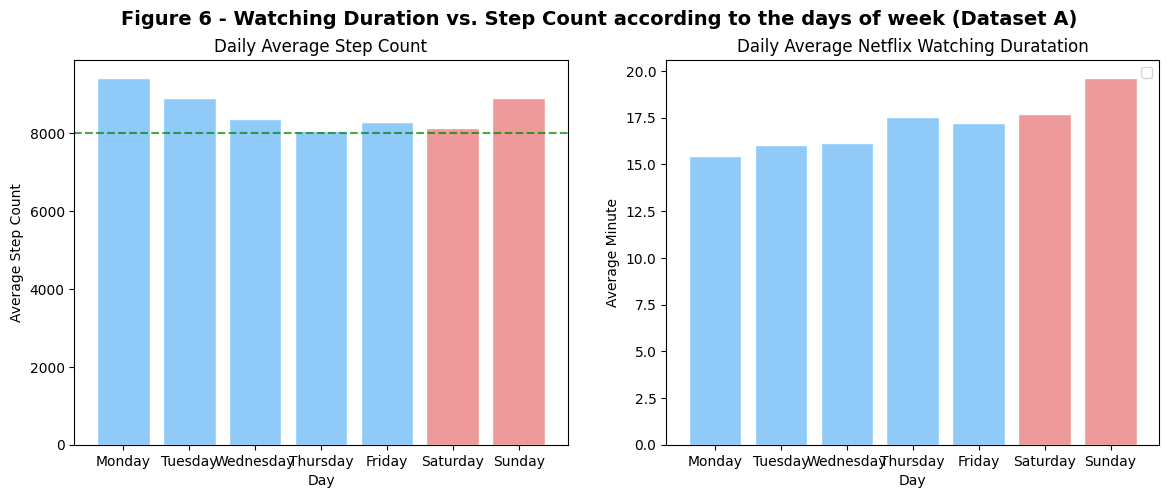

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle("Figure 6 - Watching Duration vs. Step Count according to the days of week (Dataset A)", fontsize=14, fontweight="bold")
day_name = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_stats = A.groupby("day_name").agg(step_mean=("step_count","mean"), watch_mean=("watch_minutes", "mean"))

ax = axes[0]
colors_day = ["#90CAF9"]*5 + ["#EF9A9A"]*2
ax.bar(day_name, day_stats["step_mean"], color=colors_day, edgecolor="white")
ax.axhline(8000, color="green", linewidth=1.5, linestyle="--", alpha=0.7)
ax.set_title("Daily Average Step Count")
ax.set_xlabel("Day")
ax.set_ylabel("Average Step Count")

ax = axes[1]
ax.bar(day_name, day_stats["watch_mean"], color=colors_day, edgecolor="white")
ax.set_title("Daily Average Netflix Watching Duratation")
ax.set_xlabel("Day")
ax.set_ylabel("Average Minute")

ax.legend()